# Decoding trial type from session sequences


In [1]:
prefix = '/home/ines/repositories/'
# prefix = '/Users/ineslaranjeira/Documents/Repositories/'

In [2]:
""" 
IMPORTS
"""
import os
import numpy as np
import seaborn as sns
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
# --Machine learning and statistics
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler,  LabelBinarizer
from sklearn.cluster import KMeans
import random
from sklearn import mixture
import pickle
from scipy.stats import mode
from sklearn.inspection import permutation_importance

# --Machine learning and statistics
from sklearn.model_selection import KFold
from sklearn.ensemble import RandomForestClassifier
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import f1_score, confusion_matrix
from sklearn.preprocessing import OneHotEncoder
from scipy.stats import entropy

# Get my functions
from functions import idxs_from_files, align_bin_design_matrix, states_per_trial_phase, broader_label, define_trial_types

from one.api import ONE
one = ONE(mode='remote')

In [3]:
def plot_cm(decoding_result, trial_epochs, size, control=False):
    """
    PLOT RESULTS
    """

    # -- Confusion Matrix
    # labels = trial_epochs

    # Results on original model
    plt.rc('font', size=8) 
    plt.figure(figsize=size)
    # hmap = sns.color_palette("mako", as_cmap=True)
    hmap=plt.cm.get_cmap('Greys')
    data = decoding_result.loc[decoding_result['shuffle'] == 0]
    sns.heatmap(data['confusion_matrix'].mean(), annot=False, square=True,
        yticklabels=trial_epochs, xticklabels=trial_epochs, 
        cmap= hmap, vmin=0, vmax=1, fmt=".2f") 

    # plt.xticks([.5, 1.5, 2.5, 3.5], trial_epochs)
    # plt.yticks([.5, 1.5, 2.5, 3.5], trial_epochs)
    plt.xticks(rotation = 90)
    plt.yticks(rotation = 0)
    plt.xlabel('Predicted trial type')
    plt.ylabel('True trial type')
    # plt.savefig('full_cm.svg',dpi=500)
    plt.show()
    print('F1 results', data['f1'].mean())

    if control:
        # Results from shuffled model
        plt.rc('font', size=9) 
        plt.figure(figsize=size)
        data = decoding_result.loc[decoding_result['shuffle'] >0]
        sns.heatmap(data['confusion_matrix'].mean(), annot=False, square=True,
            yticklabels=trial_epochs, xticklabels=trial_epochs, 
            cmap= hmap, vmin=0, vmax=1, fmt=".2f")

        # plt.xticks([.5, 1.5, 2.5, 3.5], trial_epochs)
        # plt.yticks([.5, 1.5, 2.5, 3.5], trial_epochs)
        plt.xticks(rotation = 90)
        plt.yticks(rotation = 0)
        plt.xlabel('Predicted mouse')
        plt.ylabel('True mouse')
        plt.show()
        print('F1 shuffled results',  data['f1'].mean())
    plt.tight_layout()

def plot_f1(decoding_result):
    # -- F1 score per model, original and shuffled
    data = decoding_result.copy()
    data['f1'] = data['f1'].astype(float)

    data.loc[data['shuffle'] >= 1, 'shuffle'] = 'Shuffled'
    data.loc[data['shuffle'] == 0, 'shuffle'] = 'Original'
    data = data.rename(columns={'shuffle': 'Dataset'})

    plt.rc('font', size=12) 
    plt.figure(figsize=[4.5, 4])
    sns.boxplot(y='f1', x='Dataset', data=data, color='grey') 
    sns.swarmplot(y='f1', x='Dataset', data=data, color='black', dodge=True, alpha=0.7, size=3)
    plt.ylim([0,1])
    plt.ylabel('Accuracy score (F1)')
    plt.legend(bbox_to_anchor=(1.05, 1))
    sns.despine(top=True, right=True)
    #plt.savefig('violin.svg',dpi=500)

In [4]:
extra_sessions = ['2d7c0f7f-e805-404b-914a-23d83998e08e',
'7691eeb3-715b-4571-8fda-6bb57aab8253',
'a28746ff-a6e0-403d-a11d-893c2f9a44b4',
'f140a2ec-fd49-4814-994a-fe3476f14e66',
'bd8b204f-a42e-45c1-a8f0-71c6223a6657',
'e4fac833-d985-4bb2-a97a-c4d7ed8d06e1',
'13b70283-e8d3-4e69-ae3f-83f50c9602e2',
'e34ee0ad-3ad8-4faa-b4d5-c1cc0cf3b496',
'f3eeb2d4-87ce-49ae-8a74-21665f6f1536',
'd9f0c293-df4c-410a-846d-842e47c6b502',
'86f741b4-9dee-4c28-8ee9-49f3656ab419',
'650a0a90-4bf3-4489-9bcd-75baf0a49eac',
'a2be3311-de26-48b3-bfc7-317e94a4fdd3',
'12f95449-6914-4d76-9eb3-7d79757a4a77',
'd9907ac3-7378-471d-91fb-c8ec34870e17',
'b4a8ec28-46ad-4b6f-908b-650d0970a0db',
'c51f34d8-42f6-4c9c-bb5b-669fd9c42cd9',
'71963e7f-5947-4c3e-bcc8-dfdef3d71be7',
'7471a326-894d-4b55-8b01-a0ad56af209c',
'8839a67d-991a-4694-9c45-b3af73ce4d36',
'db4fe6df-b1d2-4958-9c93-e71696d58f7f',
'80653a5b-c7aa-479d-9ae0-c92f296fface',
'169c9a39-cb63-4b77-93e2-10e076d4c472',
'495bee7e-b58e-42ea-8481-4a1bfedca54a',
'1db57661-5ad3-4465-b9ee-08473af9c2e8',
'3513e7f2-d2e6-4411-8055-54dac50458f6',
'd035c5ba-d51e-49a9-a94b-23531a598ec3',
'6a369bfa-a70b-4147-af25-d03772ff8d96',
'7050ae29-a99e-43f1-aa42-b4416200351c',
'3fa080ff-bcce-43e8-bd5f-601f0591f785',
'369c3073-e886-4b28-a32b-a5860df21392',
'aa8c915b-cc12-4022-8339-3faa438d7fe2',
'8b422ab2-fc98-4d25-ac1f-e239ca869d9e',
'87d86bb0-72d3-4213-be72-392295d3d601',
'2ab80a04-96f6-45f8-bf69-7eac67f81742',
'57701dff-8107-4ab6-ac7a-b087a2e4cc94',
'42541dce-2ffb-452e-bf54-119aee2ae48a',
'89848cb4-77d3-4db2-877e-2fa73a3cf5f6',
'33cbe984-deb7-489c-add6-d98ac9f64df6',
'0b5f5111-5647-4400-8e08-f57975027b5e',
'9e77877d-6fcf-4e91-9337-4b19277561d5',
'dc36f1b9-5dba-49c4-b333-ad08af6b8f86',
'8a039e2b-637e-45ed-8da6-0641924626f0',
'00d3c9ea-2c91-44c2-b03e-6dfec5e08f27',
'e698b903-98ed-48b9-bc40-664274f722da',
'e5094e8a-cd54-43d4-8a7a-c5aa54b15e19',
'09137957-7216-40ea-90b5-ef85a62b578a',
'03f0ed7f-e647-4732-ae1a-d41fc459138b',
'4373de88-6b08-4185-a224-f898fd0017d4',
'30c4e2ab-dffc-499d-aae4-e51d6b3218c2',
'1e07df0b-205b-4c94-8e02-2ae07dae4347',
'5c7d2345-1f0e-40e5-aad7-2c6133b71b09',
'1735d2be-b388-411a-896a-60b01eaa1cfe',
'14736609-bfdd-4620-8e47-09d7f4bc4412',
'4537bd9a-0a63-4462-870c-5f6d70d289ed',
'1715d2bc-4da3-4de2-9631-3ab1c600f2bf',
'aed404ce-b3fb-454b-ac43-2f12198c9eaf',
'f115196e-8dfe-4d2a-8af3-8206d93c1729',
'5c454bcb-ae77-42da-a8d2-b6463ea9f21b',
'c728f6fd-58e2-448d-aefb-a72c637b604c',
'c8fc81e8-fd09-4228-a08c-81c01f21381a',
'7502ae93-7437-4bcd-9e14-d73b51193656',
'297bd519-78f8-45d2-af85-835e865e228f',
'7b074b1a-6576-4380-91e4-ad6cdf06c3a6',
'064a7252-8e10-4ad6-b3fd-7a88a2db5463']

In [5]:
sessions_to_exclude = ['2d7c0f7f-e805-404b-914a-23d83998e08e', # bad right cam
'7691eeb3-715b-4571-8fda-6bb57aab8253', # bad view of paws
'bd8b204f-a42e-45c1-a8f0-71c6223a6657', # bad right camera
'f3eeb2d4-87ce-49ae-8a74-21665f6f1536', # moving licks
'650a0a90-4bf3-4489-9bcd-75baf0a49eac', # licks fail
'495bee7e-b58e-42ea-8481-4a1bfedca54a', # timestamps
'1db57661-5ad3-4465-b9ee-08473af9c2e8', # timestamps
'6a369bfa-a70b-4147-af25-d03772ff8d96', # timestamps
'7050ae29-a99e-43f1-aa42-b4416200351c', # timestamps
'3fa080ff-bcce-43e8-bd5f-601f0591f785', # timestamps
'5c454bcb-ae77-42da-a8d2-b6463ea9f21b', # bad licks
'c728f6fd-58e2-448d-aefb-a72c637b604c' # no data can be loaded
]

In [6]:
sessions_to_process = [x for x in extra_sessions if x not in sessions_to_exclude]

In [7]:
# Loop through animals
data_path = prefix + 'representation_learning_variability/paper-individuality/data/design_matrices/extra_bwm/'
all_files = os.listdir(data_path)
design_matrices = [item for item in all_files if 'design_matrix' in item and 'standardized' not in item]
idxs, mouse_names = idxs_from_files(design_matrices)

wheel_k = 3
paw_k = 8

paw_wavelet_path = prefix + 'representation_learning_variability/paper-individuality/data/paw_wavelets/extra_bwm/'
paw_states_path = prefix + 'representation_learning_variability/paper-individuality/data/paw_most_likely_states/'

wheel_wavelet_path = prefix + 'representation_learning_variability/paper-individuality/data/wheel_wavelets/extra_bwm/'
wheel_states_path = prefix + 'representation_learning_variability/paper-individuality/data/wheel_most_likely_states/'

In [8]:
paw_fix_mapping = {0:4, 1:1, 2:5, 3:7, 4:6, 5:2, 6:0, 7:3}
wheel_fix_mapping = {0:1, 1:0, 2:2} 

paw_func = np.vectorize(paw_fix_mapping.get)
wheel_func = np.vectorize(wheel_fix_mapping.get)

identifiable_mapping = {}

counter = 0
for wheel in [0, 1, 2]:
    for paw in range(8):
        key = f"{paw}{wheel}"
        identifiable_mapping[key] = float(counter)
        counter += 1
identifiable_mapping["nan"] = np.nan
identifiable_func = np.vectorize(identifiable_mapping.get)

In [9]:
len(idxs)

62

In [ ]:
all_sessions = pd.DataFrame()

for m, mat in enumerate(idxs):
    mouse_name = mat[37:]
    session = mat[:36]

    if session not in sessions_to_exclude:
        trials_file = data_path + "session_trials_" + str(session) + '_'  + mouse_name
        session_trials = pd.read_parquet(trials_file, engine='pyarrow').reset_index() 

        filename = data_path + "design_matrix_" + str(session) + '_'  + mouse_name
        design_matrix = pd.read_parquet(filename)
        design_matrix['paw_states'] = design_matrix['Bin'] * np.nan
        design_matrix['wheel_states'] = design_matrix['Bin'] * np.nan

        array = np.array(design_matrix[['Bin', 'avg_wheel_vel']]) 
        not_nan_wheel = ~np.isnan(array).any(axis=1)
        # Load wheel states 
        states_filename = wheel_states_path + "most_likely_states_" + str(wheel_k) + '_'  + mouse_name + session + '.npy'
        wheel_most_likely_states = np.load(open(states_filename, "rb"))
        assert len(wheel_most_likely_states) == len(design_matrix[not_nan_wheel])
        design_matrix['wheel_states'][not_nan_wheel] = wheel_func(wheel_most_likely_states)

        array = np.array(design_matrix[['Bin', 'l_paw_x', 'l_paw_y', 'r_paw_x', 'r_paw_y']]) 
        not_nan_paw = ~np.isnan(array).any(axis=1)
        # Load paw states
        states_filename = paw_states_path + "most_likely_states_" + str(paw_k) + '_'  + mouse_name + session + '.npy'
        paw_file = np.load(open(states_filename, "rb"))
        paw_most_likely_states = paw_file[0]
        paw_bins = paw_file[1]
        
        design_matrix.loc[design_matrix['Bin'].isin(paw_bins), 'paw_states'] = paw_func(paw_most_likely_states)

        design_matrix['mouse_name'] = mouse_name
        design_matrix['session'] = session

        design_matrix['identifiable_states'] = design_matrix['paw_states'].astype('Int64').astype(str) + design_matrix['wheel_states'].astype('Int64').astype(str)
        design_matrix['most_likely_states'] = identifiable_func(design_matrix['identifiable_states'])

        # Align bins
        multiplier = 1
        event_type_list = ['goCueTrigger_times']  # , 'feedback_times', 'firstMovement_times'
        event_type_name = ['Go cue']  # , 'Feedback time', 'First movement onset'
        init = -1 * multiplier
        end = 1.5 * multiplier
        empirical_data = align_bin_design_matrix(init, end, event_type_list, session_trials, design_matrix, design_matrix['most_likely_states'], multiplier)
        empirical_data = empirical_data.drop(columns=['new_bin'])
        
        """ Trial types """
        # Split in Foundtrial types
        states_trial = states_per_trial_phase(empirical_data, session_trials, multiplier)
        states_trial['mouse_name'] = mouse_name
        states_trial['session'] = session
        states_trial = broader_label(states_trial)
        states_trial = states_trial[['Bin',
                                    'correct', 'choice', 'contrast', 'block', 'reaction', 'response',
                                    'elongation', 'wsls', 'trial_id', 'goCueTrigger_times',
                                    'label', 'broader_label']]
        states_trial = states_trial.merge(design_matrix, on='Bin')
        all_sessions = pd.concat([all_sessions, states_trial])


In [13]:
# Save data
data_path = prefix + 'representation_learning_variability/paper-individuality/lightningAction/'
filename = "paw_states_24022026"
all_sessions.to_parquet(data_path+filename)  

In [10]:
# Load data
data_path = prefix + 'representation_learning_variability/paper-individuality/lightningAction/'
filename = "paw_states_24022026"
all_sessions = pd.read_parquet(data_path+filename)

In [11]:
def add_most_likely_state(df, state_columns, new_column="left_paw_cameraL"):
    """
    df : pandas DataFrame
    state_columns : list of column names containing state probabilities
    new_column : name of output column
    """

    df[new_column] = df[state_columns].idxmax(axis=1)
    return df

In [12]:
var_left = ['leftCam_paw_r_still',  'leftCam_paw_r_move',  'leftCam_paw_r_wheel_turn',  'leftCam_paw_r_groom']
var_right = ['rightCam_paw_r_still',  'rightCam_paw_r_move',  'rightCam_paw_r_wheel_turn',  'rightCam_paw_r_groom']

new_df = add_most_likely_state(all_sessions, var_left, new_column="left_paw")
new_df = add_most_likely_state(all_sessions, var_right, new_column="right_paw")

In [13]:
fix_label = {'leftCam_paw_r_still':'still',  'leftCam_paw_r_move':'move',  'leftCam_paw_r_wheel_turn':'wheel',  'leftCam_paw_r_groom':'groom',
             'rightCam_paw_r_still':'still',  'rightCam_paw_r_move':'move',  'rightCam_paw_r_wheel_turn':'wheel',  'rightCam_paw_r_groom':'groom'} 

# fix_label = {'leftCam_paw_r_still':'still',  'leftCam_paw_r_move':'move',  'leftCam_paw_r_wheel_turn':'move',  'leftCam_paw_r_groom':'groom',
#              'rightCam_paw_r_still':'still',  'rightCam_paw_r_move':'move',  'rightCam_paw_r_wheel_turn':'move',  'rightCam_paw_r_groom':'groom'} 
label_func = np.vectorize(fix_label.get)
new_df['left_paw'] = label_func(new_df['left_paw'])
new_df['right_paw'] = label_func(new_df['right_paw'])

In [14]:
new_df['identifiable_action'] = new_df['left_paw'].astype(str) + new_df['right_paw'].astype(str)
new_df['most_likely_action'] = pd.factorize(new_df['identifiable_action'])[0]

In [15]:
trial_type_agg = ['correct_str', 'contrast_str', 'block_str', 'choice']
states_df = define_trial_types(new_df, trial_type_agg)

/home/ines/repositories/representation_learning_variability/paper-individuality/lightningAction/functions.py:374: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value 'correct' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  states_trial_type.loc[states_trial_type['correct_str']==1., 'correct_str'] = 'correct'


# Syllable probability per trial epoch

In [41]:
use_states = 'most_likely_states'  # most_likely_states most_likely_action
states_df['trial_type_interest'] = states_df['trial_type'].str.split().str[2:3].str.join('').astype(str)

In [42]:
group_cols = ['mouse_name', 'session', 'trial_id', 'broader_label', 'trial_type_interest']
# Count syllables per group
data = (states_df.groupby(group_cols + [use_states]).size().reset_index(name='count'))
# Convert counts to fractions within each group
data['usage'] = (data['count'] /data.groupby(group_cols)['count'].transform('sum'))

In [43]:
design_df = data.pivot(index=['mouse_name', 'session', 'trial_id', 'trial_type_interest'], columns=['broader_label', use_states], values='usage').fillna(0).reset_index()

# Get data of interest for decoder

Text(0.5, 1.0, 'Explained Variance by PCA')

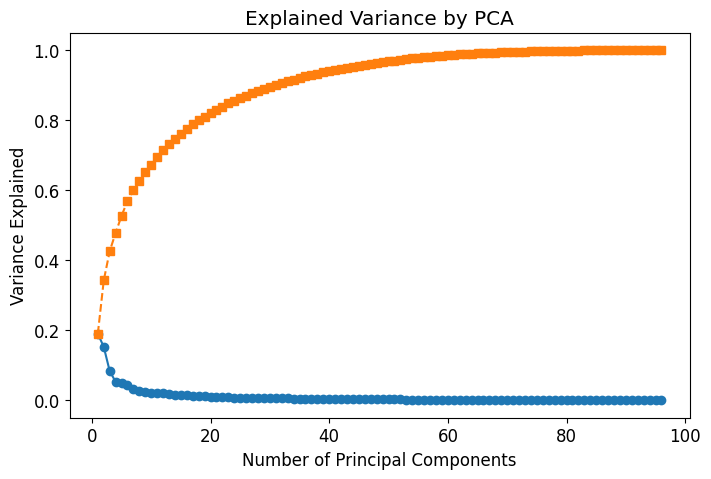

In [50]:
# PCA
X = np.array(design_df)[:, 4:].astype(float)
n_components = np.min([np.shape(X)[0], np.shape(X)[1]])
# Step 1: Reduce dimensions with PCA
pca = PCA(n_components)  # Reduce to 50 dimensions
scaler = StandardScaler()
# standardized_X = scaler.fit_transform(np.array(session_syllables))
# X_pca = pca.fit_transform(standardized_X)
X_pca = pca.fit_transform(X)

# Explained variance ratio
explained_variance_ratio = pca.explained_variance_ratio_
cumulative_variance = np.cumsum(explained_variance_ratio)

# Plot explained variance
plt.figure(figsize=(8, 5))
plt.plot(range(1, n_components+1), explained_variance_ratio, marker='o', label='Individual')
plt.plot(range(1, n_components+1), cumulative_variance, marker='s', label='Cumulative', linestyle='--')
plt.xlabel("Number of Principal Components")
plt.ylabel("Variance Explained")
plt.title("Explained Variance by PCA")

In [57]:
min_components = 64
min_components = np.min(np.where(cumulative_variance>0.95))

In [68]:
use_mat = pd.DataFrame(np.array(design_df)[:, 4:].astype(float))
# use_mat = pd.DataFrame(np.array(X_pca[:, :min_components]))

use_mat['type'] = pd.factorize(design_df['trial_type_interest'])[0]
named_labels = design_df['trial_type_interest']

Text(0, 0.5, 'Samples')

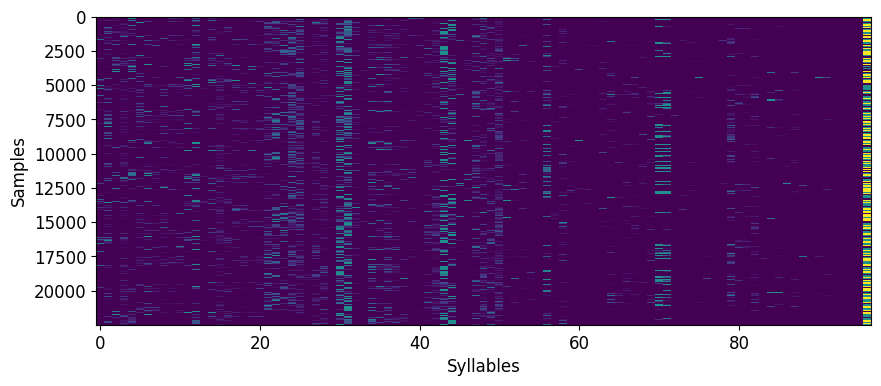

In [69]:
plt.figure(figsize=(10, 4))
plt.imshow(use_mat, aspect='auto', cmap='viridis', interpolation='none')
plt.xlabel('Syllables')
plt.ylabel('Samples')

## Decode

In [129]:
shufflings = 1  #shuffling
# model = RandomForestClassifier(max_depth=2, random_state=0)
model = RandomForestClassifier(random_state=42)
# model = MultinomialNB()
repeats = 5

var = 'type'

In [130]:
def run_decoder(use_mat, model, shufflings, repeats, var):
    """
    RUN MODEL
    """

    # Generate random states for each iteration with a fixed seed
    # Loop over iterations of random draws of mice
    # Create empty dataframes to save results
    decoding_result = pd.DataFrame(columns=['shuffle', 'repeat', 'f1', 'confusion_matrix'])
    dec_result = pd.DataFrame(columns=['shuffle', 'repeat', 'f1', 'confusion_matrix'])

    # use_mat, named_labels = prepare_mat(df, final_matrix)

    for r in range(repeats):
        print('Repeat %d of %d' % (r+1, repeats))  
        # Decoding function with 10-fold cross validation
        kf = KFold(n_splits=5, shuffle=True, random_state=0)
        # use_mat = mat.copy() # test using all mice

        # Find minimum number of samples per label
        labels = np.array(use_mat[var])
        labels_nr = np.arange(len(use_mat[var]))
        min_freq = np.min(use_mat[var].value_counts())
        # min_freq = 400

        # Randomly select N mice from each quartile to equalize classes
        use_index = np.empty(0, dtype=int)
        for j, epoch in enumerate(np.unique(labels)):
            use_index = np.concatenate([use_index, np.random.choice(labels_nr[labels == epoch],
                                                                    min_freq, replace=False)])

        new_mat = use_mat.iloc[use_index].reset_index().drop(columns=['index']).copy()
                
        # -- ORIGINAL DATASET
        y_pred = np.zeros(len(new_mat), dtype=int) 
        exog = new_mat[new_mat.columns.difference([var])]
        endog = new_mat.loc[:, var].copy()

        for train_index, test_index in kf.split(new_mat):
            model.fit(exog.iloc[train_index], endog.iloc[train_index].astype(int))
            y_pred[test_index] = model.predict(exog.iloc[test_index])

        # Calculate f1 score and confusion matrix
        f1 = f1_score(endog.astype(int), y_pred.astype('int'), average='micro')
        cm = confusion_matrix(endog.astype(int), y_pred.astype('int'), normalize='true')

        # Save results
        dec_result.loc[0, 'f1'] = f1
        dec_result.loc[0, 'confusion_matrix'] = cm
        dec_result.loc[0, 'shuffle'] = 0
        dec_result.loc[0, 'repeat'] = r

        decoding_result = pd.concat([decoding_result, dec_result])

        # -- SHUFFLED DATASET 
        shuffle_result = pd.DataFrame(columns=['shuffle', 'f1', 'confusion_matrix'])
        for s in range(shufflings):
            if np.mod(s+1, 10) == 0:
                print('Shuffling %d of %d' % (s+1, shufflings))   

            shuffle_y_pred = np.zeros(len(new_mat), dtype=int) 
            shuffle_endog = endog.copy()
            np.random.shuffle(shuffle_endog.values)

            for train_index, test_index in kf.split(new_mat):
                model.fit(exog.iloc[train_index], list(shuffle_endog.iloc[train_index].astype(int)))
                shuffle_y_pred[test_index] = model.predict(exog.iloc[test_index])   

            shuffle_f1 = f1_score(shuffle_endog.astype(int), shuffle_y_pred.astype('int'), average='micro')
            shuffle_cm = confusion_matrix(shuffle_endog.astype(int), shuffle_y_pred.astype('int'), normalize='true')

            # SAVE
            shuffle_result.loc[s, 'f1'] = shuffle_f1
            shuffle_result.loc[s, 'confusion_matrix'] = shuffle_cm
            shuffle_result.loc[s, 'shuffle'] = s + 1

        decoding_result = pd.concat([decoding_result, shuffle_result])
    
    return decoding_result

/tmp/ipykernel_25292/1075342677.py:13: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  hmap=plt.cm.get_cmap('Greys')


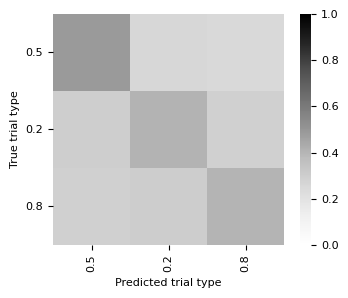

F1 results 0.43303700326722894


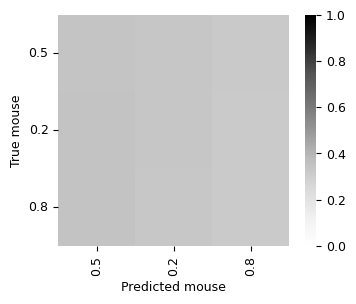

F1 shuffled results 0.3326342983055999


/tmp/ipykernel_25292/1075342677.py:63: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(bbox_to_anchor=(1.05, 1))


<Figure size 640x480 with 0 Axes>

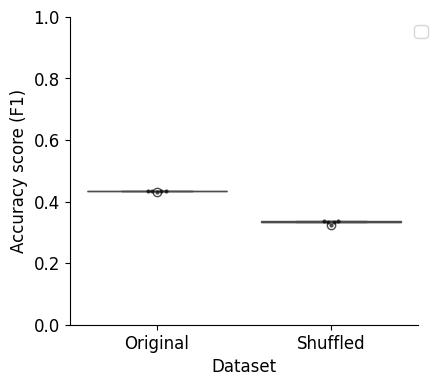

In [72]:
plot_cm(decoding_result, named_labels.drop_duplicates().dropna(), [4, 3], control=True)
plot_f1(decoding_result)

In [ ]:
all_results = pd.DataFrame(columns=['state', 'type', 'f1', 'cm', 'f1_shuffle', 'cm_shuffle'])

for s, st in enumerate(['most_likely_states',  'paw_states',  'most_likely_action']):
    for t, typ in enumerate([0, 1, 2, 3]):
        use_states = st 
        states_df['trial_type_interest'] = states_df['trial_type'].str.split().str[typ:typ+1].str.join('').astype(str)

        group_cols = ['mouse_name', 'session', 'trial_id', 'broader_label', 'trial_type_interest']
        # Count syllables per group
        data = (states_df.groupby(group_cols + [use_states]).size().reset_index(name='count'))
        # Convert counts to fractions within each group
        data['usage'] = (data['count'] /data.groupby(group_cols)['count'].transform('sum'))
        design_df = data.pivot(index=['mouse_name', 'session', 'trial_id', 'trial_type_interest'], columns=['broader_label', use_states], values='usage').fillna(0).reset_index()

        use_mat = pd.DataFrame(np.array(design_df)[:, 4:].astype(float))
        # use_mat = pd.DataFrame(np.array(X_pca[:, :min_components]))

        use_mat['type'] = pd.factorize(design_df['trial_type_interest'])[0]
        named_labels = design_df['trial_type_interest']

        decoding_result = run_decoder(use_mat, model, shufflings, repeats, var)
        
        result = pd.DataFrame(columns=['state', 'type', 'f1', 'cm', 'f1_shuffle', 'cm_shuffle'], index=range(repeats))
        result['state'] = st
        result['type'] = typ
        result['f1'] = list(decoding_result.loc[decoding_result['shuffle']==0, 'f1'])
        result['cm'] = list(decoding_result.loc[decoding_result['shuffle']==0, 'confusion_matrix'])
        result['f1_shuffle'] = list(decoding_result.loc[decoding_result['shuffle']>0, 'f1'])
        result['cm_shuffle'] = list(decoding_result.loc[decoding_result['shuffle']>0, 'confusion_matrix'])

        # Save
        all_results = pd.concat([all_results, result])


In [133]:
# Save data
data_path = prefix + 'representation_learning_variability/paper-individuality/lightningAction/'
filename = "all_decoders_25022026"
all_results.to_pickle(data_path+filename)  

In [134]:
trial_type_agg = ['correct_str', 'contrast_str', 'block_str', 'choice']

In [135]:
all_results['trial_type'] = all_results['type']
all_results.loc[all_results['type']==0, 'trial_type'] = 'Feedback'
all_results.loc[all_results['type']==1, 'trial_type'] = 'Contrast'
all_results.loc[all_results['type']==2, 'trial_type'] = 'Block'
all_results.loc[all_results['type']==3, 'trial_type'] = 'Choice'

In [136]:
pivot_decoders = pd.melt(all_results, id_vars=["state", 'trial_type'], value_vars=["f1", "f1_shuffle"])


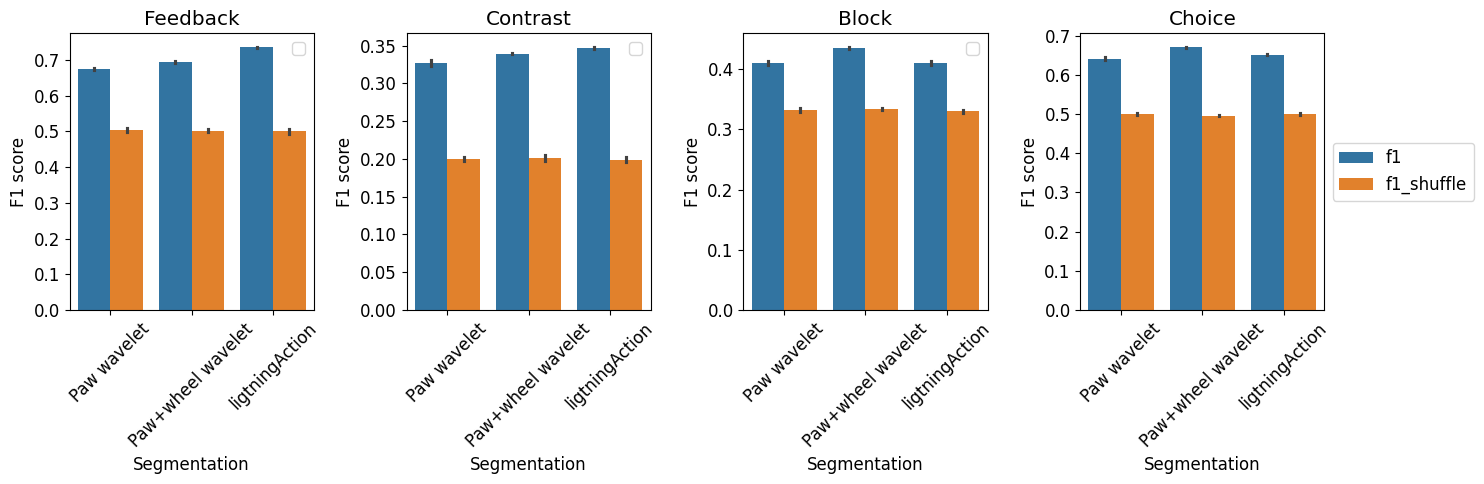

In [137]:
fig, ax = plt.subplots(ncols=4 , nrows=1, sharex=False, sharey=False, figsize=[15, 5])
for v, variable in enumerate(pivot_decoders.trial_type.unique()):
    sns.barplot(x='state', y='value', hue='variable', order = ['paw_states', 'most_likely_states', 'most_likely_action'],
                data=pivot_decoders.loc[pivot_decoders['trial_type']==variable], ax=ax[v])
    ax[v].set_ylabel('F1 score')
    ax[v].set_xlabel('Segmentation')
    ax[v].set_xticks([0, 1, 2], ['Paw wavelet', 'Paw+wheel wavelet', 'ligtningAction'], rotation=45)
    ax[v].legend('')
    
    # ax[v].set_ylim([np.min(pivot_decoders.loc[pivot_decoders['trial_type']==var, 'value'])-.1,
    #                 np.max(pivot_decoders.loc[pivot_decoders['trial_type']==var, 'value'])+.1])
    ax[v].set_title(variable)
plt.legend(loc = "center left", bbox_to_anchor = (1, 0.5))
plt.tight_layout()